# Análise Estatística

In [1]:
import pandas as pd
import scipy.stats as stats
import seaborn as sns
import matplotlib.pyplot as plt
import sys
import os

# Adiciona o diretório raiz ao path para conseguir importar o config
sys.path.append(os.path.abspath(".."))
from src.config import get_engine

engine = get_engine()

# Buscando a Tabela Fato direto do banco de dados na Nuvem (Neon)
query = "SELECT * FROM analytics.fact_orders"
df = pd.read_sql(query, engine)
print(f"Base carregada: {df.shape[0]} pedidos na tabela fato.")

Base carregada: 96470 pedidos na tabela fato.


## 0. Verificação das Distribuições 

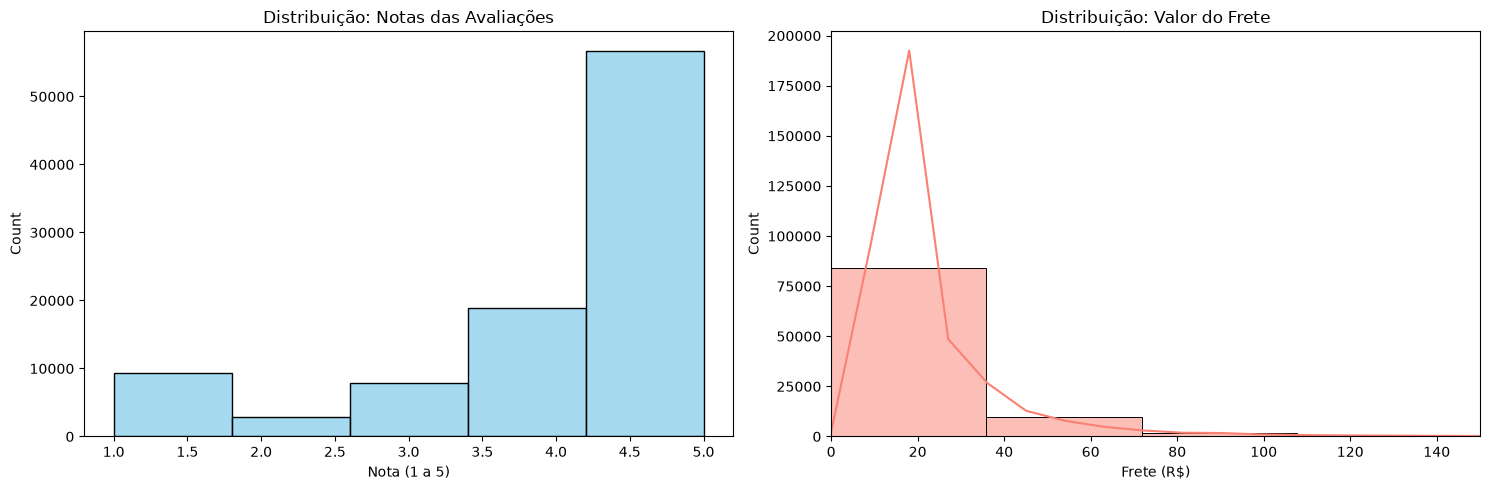

Teste de Normalidade para 'Nota': P-Valor = 0.000e+00
Teste de Normalidade para 'Valor do Frete': P-Valor = 0.000e+00


In [2]:
import scipy.stats as stats

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Distribuição da Nota (review_score)
sns.histplot(df['review_score'].dropna(), bins=5, kde=False, ax=axes[0], color='skyblue')
axes[0].set_title('Distribuição: Notas das Avaliações')
axes[0].set_xlabel('Nota (1 a 5)')

# Distribuição do Valor do Frete (frete_total)
sns.histplot(df['frete_total'].dropna(), bins=50, kde=True, ax=axes[1], color='salmon')
axes[1].set_title('Distribuição: Valor do Frete')
axes[1].set_xlabel('Frete (R$)')
axes[1].set_xlim(0, 150) # Limitando o eixo X para facilitar a visualização de outliers

plt.tight_layout()
plt.show()

# Teste de Normalidade de D'Agostino's K-squared (normaltest)
# Usado no lugar de Shapiro-Wilk pois N > 5000
stat_nota, p_nota = stats.normaltest(df['review_score'].dropna())
stat_frete, p_frete = stats.normaltest(df['frete_total'].dropna())

print(f"Teste de Normalidade para 'Nota': P-Valor = {p_nota:.3e}")
print(f"Teste de Normalidade para 'Valor do Frete': P-Valor = {p_frete:.3e}")

> **Conclusão preliminar:** Em ambos os casos, o P-Valor é 0.000 (menor que 0.05). Portanto, **rejeitamos a hipótese de normalidade**. As variáveis não são normais. O objetivo aqui será validar hipóteses de negócios usando testes estatísticos não paramétricos, pois as variáveis Nota e Valor Frete não seguem a distribuição normal

## Hipótese 1: O Atraso destrói a satisfação do cliente?
Vamos testar estatisticamente se a mediana das notas de pedidos atrasados é MENOR que a de pedidos no prazo.

**Teste Utilizado:** Mann-Whitney U (ideal para notas ordinais de 1 a 5).

In [3]:
g0 = df.loc[df.flag_atraso == 0, "review_score"].dropna()
g1 = df.loc[df.flag_atraso == 1, "review_score"].dropna()

# H1: A nota de quem recebe NO PRAZO (g0) é MAIOR que quem recebe ATRASADO (g1)
stat, p = stats.mannwhitneyu(g0, g1, alternative="greater")

print(f"Mediana de estrelas (No prazo): {g0.median()}")
print(f"Mediana de estrelas (Atrasado): {g1.median()}")
print(f"P-Valor: {p:.3e}")

Mediana de estrelas (No prazo): 5.0
Mediana de estrelas (Atrasado): 2.0
P-Valor: 0.000e+00


> **Conclusão:** Rejeitamos a Hipótese Nula (H0)! O atraso comprovadamente reduz a nota do cliente de forma ESTATISTICAMENTE SIGNIFICATIVA.

## Hipótese 2: O Custo de Frete varia muito entre regiões?
Vamos testar se há diferença significativa na distribuição de Frete entre os 5 principais estados consumidores.

**Teste Utilizado:** Kruskal-Wallis H-test (alternativa não paramétrica à ANOVA).

Kruskal-Wallis P-Valor: 0.000e+00



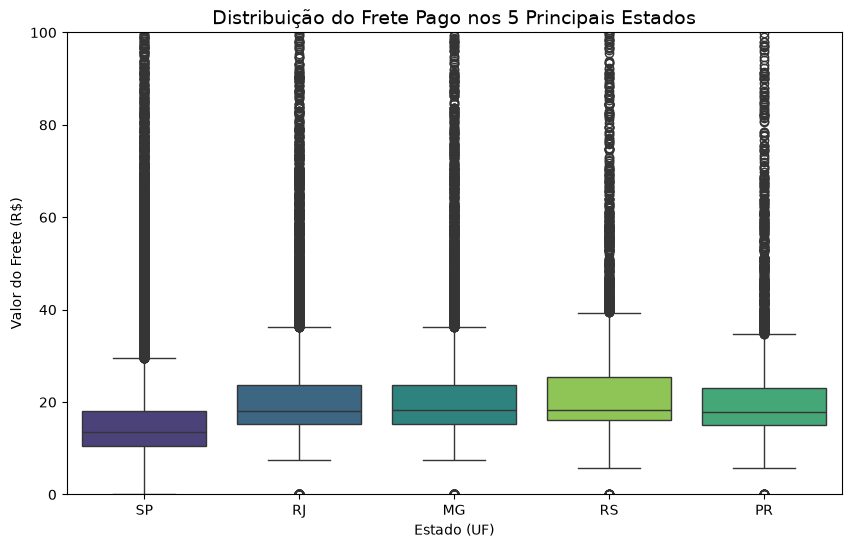

In [4]:
import numpy as np

# Separar as listas de frete dos 5 estados com mais vendas
top_ufs = df["uf_cliente"].value_counts().head(5).index
fretes_por_uf = [df.loc[(df.uf_cliente == uf) & (df.frete_total.notnull()), "frete_total"] for uf in top_ufs]

stat, p = stats.kruskal(*fretes_por_uf)
print(f"Kruskal-Wallis P-Valor: {p:.3e}\n")


plt.figure(figsize=(10,6))
sns.boxplot(data=df[df["uf_cliente"].isin(top_ufs)], x="uf_cliente", y="frete_total", order=top_ufs, palette="viridis", hue="uf_cliente", legend=False)
plt.ylim(0, 100)
plt.title("Distribuição do Frete Pago nos 5 Principais Estados", fontsize=14)
plt.xlabel("Estado (UF)")
plt.ylabel("Valor do Frete (R$)")
plt.show()

> **Conclusão:** O estado influencia significativamente o valor do frete pago pelo cliente.